# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [46]:
base = pd.read_csv("_CARDIO_BASE.csv", delimiter=';')

In [47]:
base.info()
base.isnull().sum()
# Não temos dados nulos no dataset, o que é ótimo para a análise e modelagem.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64

In [48]:
base.describe()

,age,gender,height,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


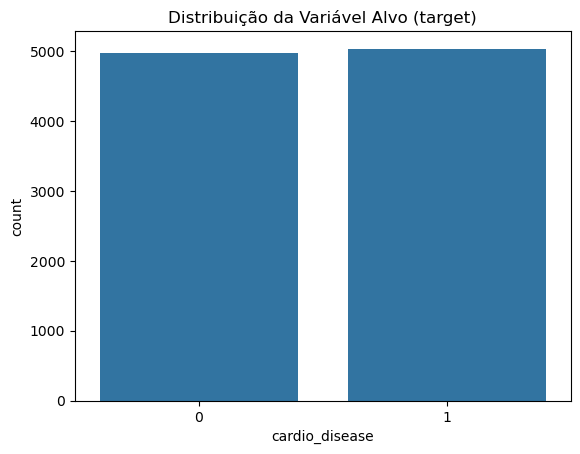

In [49]:
# Distribuição da variável alvo (target)
sns.countplot(x='cardio_disease', data=base)
plt.title('Distribuição da Variável Alvo (target)')
plt.show()


In [50]:
# Transformando a variável 'weight' em inteiro para evitar problemas de tipo de dados

base['weight'] = base['weight'].str.replace(',', '.').astype(float)
base['weight']

0       62.0
1       85.0
2       64.0
3       82.0
4       56.0
        ... 
9995    65.0
9996    93.0
9997    66.0
9998    70.0
9999    68.0
Name: weight, Length: 10000, dtype: float64

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


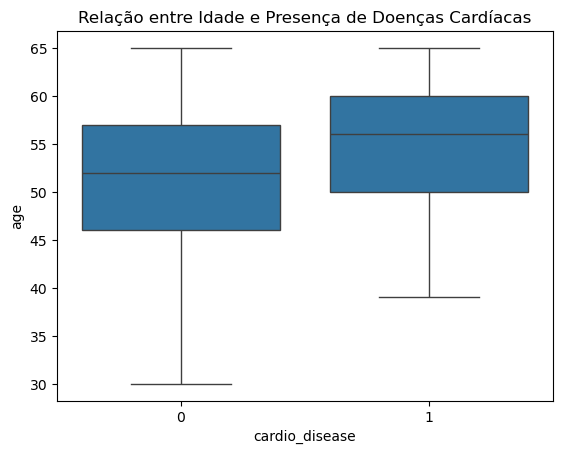

In [51]:
# Gráfico para visulizar a relação entre idade e presença de doenças cardiacas
sns.boxplot(x='cardio_disease', y='age', data=base)
plt.title('Relação entre Idade e Presença de Doenças Cardíacas')
plt.show()

# Apesar de pequena a diferença, podemos observar que as doenças cardiacas são mais frequentes em pessoas mais velhas, o que é consistente com o conhecimento médico de que a idade é um fator de risco para doenças cardíacas.


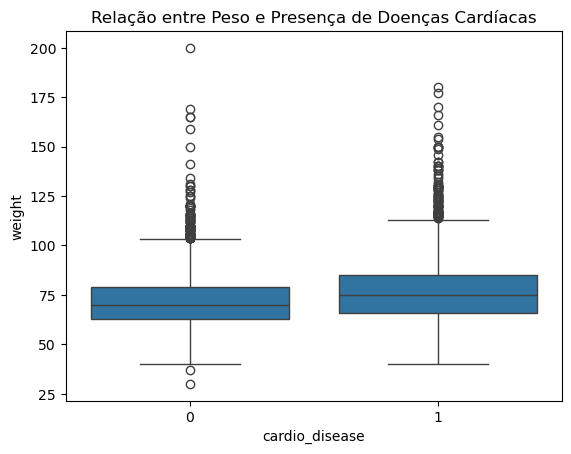

In [52]:
# Gráfico de relação entre peso e doenças cardiacas
sns.boxplot(x='cardio_disease', y='weight', data=base)
plt.title('Relação entre Peso e Presença de Doenças Cardíacas')
plt.show()

# Apesar de pequena a diferença, podemos observar que as doenças cardiacas são mais frequentes em pessoas com peso mais elevado, o que é consistente com o conhecimento médico de que o excesso de peso é um fator de risco para doenças cardíacas.

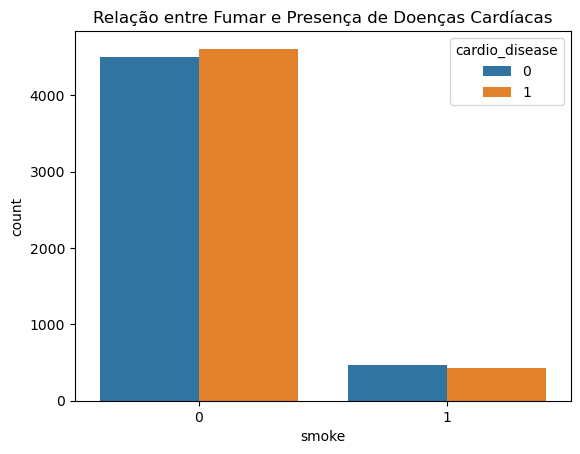

In [53]:
# Gráfico relacionando se fumar altera a chance de ter doenças cardiacas
sns.countplot(x='smoke', hue='cardio_disease', data=base)
plt.title('Relação entre Fumar e Presença de Doenças Cardíacas')
plt.show()

# Surpreendemente, não há uma grande diferença na presença de doenças cardiacas entre fumantes e não fumantes, o que pode indicar que outros fatores estão mais fortemente associados às doenças cardiacas neste dataset específico.



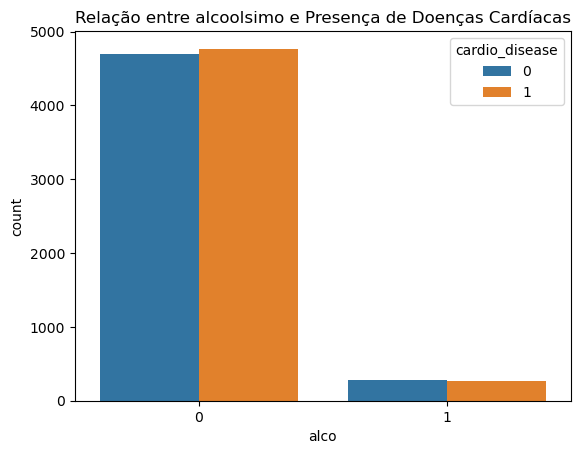

In [54]:
# Gráfico relaçionando se o alcolismo altera a chance de ter doenças cardiacas
sns.countplot(x='alco', hue='cardio_disease', data=base)
plt.title('Relação entre alcoolsimo e Presença de Doenças Cardíacas')
plt.show()

# Surpreendentemente, não há uma grande diferença na presença de doenças cardiacas entre alcoolistas e não alcoolistas.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



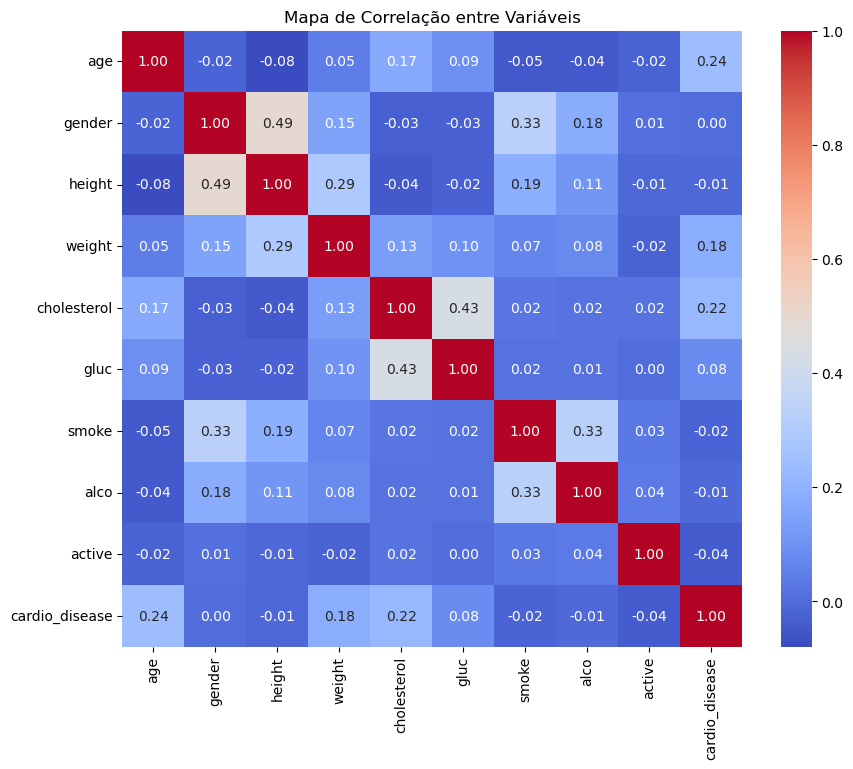

In [55]:
# Gráfico de correlação entre as variáveis numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(base.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlação entre Variáveis')
plt.show()



In [56]:
# Aparentemente, não há insights muito valiosos a serem retirados desse gráfico, já que não consegumos analisar correlações fortes entre as variáveis.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [57]:
# A)
X = base.drop('cardio_disease', axis=1)
y = base['cardio_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# D) Verificando as proporções das classes no conjunto de treinamento
print(X_train, y_train)
print('---------------------------------------')
print(X_test, y_test)

# está com uma prporoção boa.


      age  gender  height  weight  cholesterol  gluc  smoke  alco  active
9254   54       1     154    79.0            1     1      0     0       1
1561   52       2     165    65.0            1     1      0     0       1
1670   63       1     162    73.0            1     1      0     0       0
6087   62       2     173   100.0            1     1      1     0       1
6669   62       1     164    78.0            1     1      0     0       1
...   ...     ...     ...     ...          ...   ...    ...   ...     ...
5734   52       1     165    65.0            1     1      0     0       0
5191   58       2     177   121.0            1     1      0     0       0
5390   56       2     172    56.0            2     1      0     1       1
860    50       1     167    70.0            1     1      0     0       0
7270   56       2     175   109.0            1     1      0     0       1

[8000 rows x 9 columns] 9254    0
1561    0
1670    1
6087    1
6669    0
       ..
5734    1
5191    0
5390   

In [58]:
# Verificando o balanceamento das classes
base['cardio_disease'].value_counts(normalize=True)

# Os dados estão relativamente balanceados, com aproximadamente 50% de cada classe, o que é ideal para a modelagem de classificação.

cardio_disease
1    0.5031
0    0.4969
Name: proportion, dtype: float64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [59]:
# Treinando o modelo de Regressão Logística
modelo = LogisticRegression(random_state=0)
modelo.fit(X_train, y_train)

# Trazendo os coeficientes do modelo
coeficientes = pd.DataFrame({'Variável': X.columns, 'Coeficiente': modelo.coef_[0]})
print(coeficientes)

# Como temos muitas linhas de dados, os coeficinetes ficarão com numeros pequenos, o que é normal.

      Variável  Coeficiente
0          age     0.056511
1       gender     0.237266
2       height    -0.029823
3       weight     0.024894
4  cholesterol     0.587764
5         gluc    -0.123661
6        smoke    -0.232755
7         alco    -0.067215
8       active    -0.207598


c:\Users\davie\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Avaliando o modelo com a base de treino 
previsao = modelo.predict(X_train)
print(f'O modelo de Regressão Logística apresentou uma acurácia de {accuracy_score(y_train, previsao):.2f} no conjunto de treinamento.')

# o modelo aprenseta uma acurácia boa de 0.63, oque é um bom número para um modelo de classificação.

# Relatório de classificação para o conjunto de teste
relatorio = classification_report(y_train, previsao)
print(relatorio)

# Ao analisar, temos que o modelo tem uma boa precisão para a classe 0 (não tem doença cardíaca), mas uma precisão muito baixa para a classe 1 (tem doença cardíaca). Isso indica que o modelo tem dificuldade em identificar corretamente os casos de doença cardíaca, o que pode ser um problema dependendo do contexto de aplicação. A acurácia geral é de 0.63, mas a baixa precisão para a classe 1 sugere que o modelo pode não ser confiável para detectar casos de doença cardíaca.


O modelo de Regressão Logística apresentou uma acurácia de 0.63 no conjunto de treinamento.
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      3968
           1       0.64      0.61      0.63      4032

    accuracy                           0.63      8000
   macro avg       0.63      0.63      0.63      8000
weighted avg       0.63      0.63      0.63      8000



# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [ ]:
previsao_teste = modelo.predict(X_test)
print(f'O modelo de Regressão Logística apresentou uma acurácia de {accuracy_score(y_test, previsao_teste):.2f} no conjunto de teste.')
relatorio_teste = classification_report(y_test, previsao_teste)
print(relatorio_teste)

# Apesar de apresentar uma acuracia maior, o modelo ainda não está bom o suficiente para identificar os casos de doença cardíaca, o que é evidenciado pela baixa precisão e recall para a classe 1.
 


O modelo de Regressão Logística apresentou uma acurácia de 0.65 no conjunto de teste.
              precision    recall  f1-score   support

           0       0.64      0.69      0.66      1001
           1       0.66      0.61      0.64       999

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



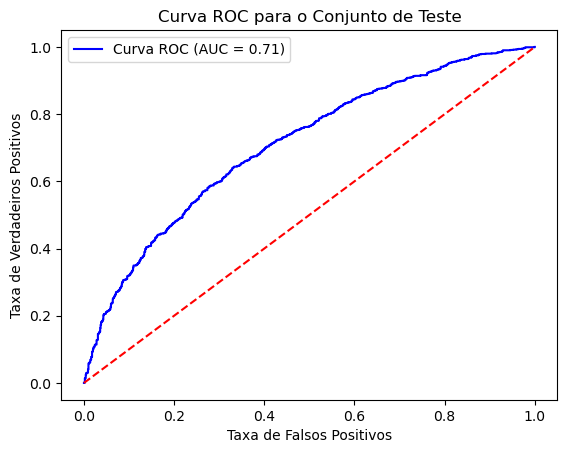

In [74]:
# Plotando a curva ROC para o conjunto de teste
y_prob = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC para o Conjunto de Teste')
plt.legend()
plt.show()


In [ ]:
# EXTRA (Pessoal)
# Teste do modelo apos a aplicação do SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
modelo_balanced = LogisticRegression(random_state=0)
modelo_balanced.fit(X_train_smote, y_train_smote)

# Avaliação do modelo apos o balanceamento com SMOTE
previsao_balanced = modelo_balanced.predict(X_test)
print(f'O modelo de Regressão Logística balanceado apresentou uma acurácia de {accuracy_score(y_test, previsao_balanced):.2f} no conjunto de teste.')
relatorio_balanced = classification_report(y_test, previsao_balanced)
print(relatorio_balanced)

# Mesmo apos o balanceamneto, o modelo não apresentou grande diferenças na acurácia ou na precisão para a classe 1, o que sugere que o modelo pode estar sofrendo de outros problemas, como falta de variáveis relevantes ou um modelo inadequado para os dados.

O modelo de Regressão Logística balanceado apresentou uma acurácia de 0.65 no conjunto de teste.
              precision    recall  f1-score   support

           0       0.64      0.70      0.67      1001
           1       0.67      0.61      0.63       999

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



c:\Users\davie\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



Ao meu ver, a regressão logistica pode ser MUITO bem utilizada na area de dados, principalmente para problemas de classificação binária, além do gráfico ROC, que deixa o modelo mais visual e fácil de entender, oque é um ponto, ao meu ver, muito positivo para um modelo de ML.
A regressão logistica é um modelo de classificação pois ela é utilizada para prever a probabilidade de uma vairavel pertencer a alguma classe, geralmente em problemas de classificação binária. 
A regressão logistica e a linear se igualam no sentido de que ambas são modelos de regressão, mas a regressão linear é usada para prever valores contínuos, enquanto a regressão logística é usada para prever probabilidades e classificar dados em categorias. A regressão logística utiliza a função logística (sigmoid) para transformar a saída linear em uma probabilidade entre 0 e 1, o que a torna adequada para problemas de classificação.